In [66]:
import pandas as pd

### Data source links from ESPNCricinfo

In [67]:
odi_url = "https://stats.cricinfo.com/ci/engine/stats/index.html?class=9;filter=advanced;orderby=wickets;size=200;template=results;type=bowling"
t20i_url = "https://stats.cricinfo.com/ci/engine/stats/index.html?class=10;filter=advanced;orderby=wickets;size=200;template=results;type=bowling"
test_url = "https://stats.cricinfo.com/ci/engine/stats/index.html?class=8;filter=advanced;orderby=wickets;size=200;template=results;type=bowling"

In [68]:
odi_stats = pd.read_html(odi_url)
df_women_bowlers = pd.DataFrame(odi_stats[2])
df_women_bowlers

,Player,Span,Mat,Inns,Overs,Mdns,Runs,Wkts,BBI,Ave,Econ,SR,4,5,Unnamed: 14
0,J Goswami (IND-W),2002-2022,204,203,1667.3,265,5622,255,6/31,22.04,3.37,39.2,7,2,NaN
1,S Ismail (SA-W),2007-2022,127,126,1028.2,133,3812,191,6/10,19.95,3.70,32.3,6,2,NaN
2,M Kapp (SA-W),2009-2025,162,152,1141.5,123,4388,181,5/20,24.24,3.84,37.8,4,2,NaN
3,CL Fitzpatrick (AUS-W),1993-2007,109,109,1002.5,188,3023,180,5/14,16.79,3.01,33.4,7,4,NaN
4,A Mohammed (WI-W),2003-2022,141,134,1042.0,102,3735,180,7/14,20.75,3.58,34.7,7,6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,M Daniels (SA-W),2010-2017,33,33,232.5,24,931,28,4/25,33.25,3.99,49.8,1,0,NaN
196,P Dimri (IND-W),2006-2010,23,23,202.5,22,650,28,3/14,23.21,3.20,43.4,0,0,NaN
197,AM Dodd (NZ-W),2002-2006,31,29,207.1,24,755,28,3/13,26.96,3.64,44.3,0,0,NaN
198,CE Eksteen (SA-W),1997-2004,36,32,247.4,34,863,28,4/4,30.82,3.48,53.0,1,0,NaN


## Removing columns that are not needed from the scraped data

In [69]:
df_women_bowlers.drop(columns=["Unnamed: 14", "Span", "Mat", "Overs", "Mdns", "BBI", "4", "5"], inplace = True)
df_women_bowlers["Format"] = "One Dayers"
df_women_bowlers

,Player,Inns,Runs,Wkts,Ave,Econ,SR,Format
0,J Goswami (IND-W),203,5622,255,22.04,3.37,39.2,One Dayers
1,S Ismail (SA-W),126,3812,191,19.95,3.70,32.3,One Dayers
2,M Kapp (SA-W),152,4388,181,24.24,3.84,37.8,One Dayers
3,CL Fitzpatrick (AUS-W),109,3023,180,16.79,3.01,33.4,One Dayers
4,A Mohammed (WI-W),134,3735,180,20.75,3.58,34.7,One Dayers
...,...,...,...,...,...,...,...,...
195,M Daniels (SA-W),33,931,28,33.25,3.99,49.8,One Dayers
196,P Dimri (IND-W),23,650,28,23.21,3.20,43.4,One Dayers
197,AM Dodd (NZ-W),29,755,28,26.96,3.64,44.3,One Dayers
198,CE Eksteen (SA-W),32,863,28,30.82,3.48,53.0,One Dayers


In [71]:
# Getting data for the top T20 bowlers
t20i_stats = pd.read_html(t20i_url)
df_t20i = pd.DataFrame(t20i_stats[2])
df_t20i

,Player,Span,Mat,Inns,Overs,Mdns,Runs,Wkts,BBI,Ave,Econ,SR,4,5,Unnamed: 14
0,DB Sharma (IND-W),2016-2026,149,146,527.0,13,3349,168,5/10,19.93,6.35,18.8,1,2,NaN
1,T Putthawong (THA-W),2019-2026,105,102,366.1,38,1464,165,5/3,8.87,3.99,13.3,6,3,NaN
2,H Ishimwe (RWA-W),2019-2026,134,128,402.1,23,1796,164,5/6,10.95,4.46,14.7,7,2,NaN
3,S Ecclestone (ENG-W),2016-2026,113,112,419.3,10,2532,154,4/18,16.44,6.03,16.3,2,0,NaN
4,M Schutt (AUS-W),2013-2026,126,125,424.1,11,2713,152,5/15,17.84,6.39,16.7,4,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Khadija Tul Kubra (BAN-W),2012-2020,49,48,150.2,4,794,43,3/5,18.46,5.28,20.9,0,0,NaN
196,S Kotte (UAE-W),2019-2026,61,54,141.4,10,567,43,4/11,13.18,4.00,19.7,1,0,NaN
197,CS Nascimento (BRA-W),2022-2026,47,40,120.4,8,583,43,5/12,13.55,4.83,16.8,1,1,NaN
198,S Nitschke (AUS-W),2005-2011,36,35,128.0,4,705,43,4/21,16.39,5.50,17.8,1,0,NaN


In [72]:
# Removing the columns that are not needed from the data and adding a new column for classifying the format
df_t20i.drop(columns=["Unnamed: 14", "Span", "Mat", "Overs", "Mdns", "BBI", "4", "5"], inplace = True)
df_t20i["Format"] = "T20Is"

#Adding the new data for T20I bowlers to the old dataframe
df_women_bowlers = pd.concat([df_women_bowlers, df_t20i], ignore_index = True)
df_women_bowlers

,Player,Inns,Runs,Wkts,Ave,Econ,SR,Format
0,J Goswami (IND-W),203,5622,255,22.04,3.37,39.2,One Dayers
1,S Ismail (SA-W),126,3812,191,19.95,3.70,32.3,One Dayers
2,M Kapp (SA-W),152,4388,181,24.24,3.84,37.8,One Dayers
3,CL Fitzpatrick (AUS-W),109,3023,180,16.79,3.01,33.4,One Dayers
4,A Mohammed (WI-W),134,3735,180,20.75,3.58,34.7,One Dayers
...,...,...,...,...,...,...,...,...
395,Khadija Tul Kubra (BAN-W),48,794,43,18.46,5.28,20.9,T20Is
396,S Kotte (UAE-W),54,567,43,13.18,4.00,19.7,T20Is
397,CS Nascimento (BRA-W),40,583,43,13.55,4.83,16.8,T20Is
398,S Nitschke (AUS-W),35,705,43,16.39,5.50,17.8,T20Is


In [73]:
# Getting data for the top Test bowlers
test_stats = pd.read_html(test_url)
df_test = pd.DataFrame(test_stats[2])
df_test

,Player,Span,Mat,Inns,Balls,Runs,Wkts,BBI,BBM,Ave,Econ,SR,5,10,Unnamed: 14
0,MB Duggan (ENG-W),1949-1963,17,27,3734,1039,77,7/6,9/58,13.49,1.66,48.4,5,0,NaN
1,ER Wilson (AUS-W),1948-1958,11,21,2885,803,68,7/7,11/16,11.80,1.67,42.4,4,2,NaN
2,DF Edulji (IND-W),1976-1991,20,35,5098,1624,63,6/64,6/64,25.77,1.91,80.9,1,0,NaN
3,CL Fitzpatrick (AUS-W),1991-2006,13,24,3603,1147,60,5/29,9/112,19.11,1.91,60.0,2,0,NaN
4,S Kulkarni (IND-W),1976-1991,19,32,3320,1647,60,6/99,7/57,27.45,2.97,55.3,5,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,SG Satghare (IND-W),2026-2026,2,3,202,97,6,4/50,4/57,16.16,2.88,33.6,0,0,NaN
196,GA Smith (ENG-W),1986-1987,4,7,706,327,6,2/30,2/83,54.50,2.77,117.6,0,0,NaN
197,MA Webb (NZ-W),1957-1961,4,2,186,66,6,3/32,6/66,11.00,2.12,31.0,0,0,NaN
198,EPN Allan (NZ-W),1972-1977,4,7,536,138,5,3/38,3/65,27.60,1.54,107.2,0,0,NaN


In [74]:
# Removing the columns that are not needed from the data and adding a new column for classifying the format
df_test.drop(columns=["Unnamed: 14", "Span", "Mat", "Balls", "BBI", "BBM", "5", "10"], inplace = True)
df_test["Format"] = "Tests"

#Adding the new data for Test bowlers to the old dataframe
df_women_bowlers = pd.concat([df_women_bowlers, df_test], ignore_index = True)
df_women_bowlers

,Player,Inns,Runs,Wkts,Ave,Econ,SR,Format
0,J Goswami (IND-W),203,5622,255,22.04,3.37,39.2,One Dayers
1,S Ismail (SA-W),126,3812,191,19.95,3.70,32.3,One Dayers
2,M Kapp (SA-W),152,4388,181,24.24,3.84,37.8,One Dayers
3,CL Fitzpatrick (AUS-W),109,3023,180,16.79,3.01,33.4,One Dayers
4,A Mohammed (WI-W),134,3735,180,20.75,3.58,34.7,One Dayers
...,...,...,...,...,...,...,...,...
595,SG Satghare (IND-W),3,97,6,16.16,2.88,33.6,Tests
596,GA Smith (ENG-W),7,327,6,54.50,2.77,117.6,Tests
597,MA Webb (NZ-W),2,66,6,11.00,2.12,31.0,Tests
598,EPN Allan (NZ-W),7,138,5,27.60,1.54,107.2,Tests


## Adding two new columns to split the data of player name and country

In [76]:
df_women_bowlers[["Name", "Country"]] = df_women_bowlers["Player"].str.split("(", expand = True)
df_women_bowlers["Country"] = df_women_bowlers["Country"].str.replace("-W)", "")
df_women_bowlers["Name"] = df_women_bowlers["Name"].str.rstrip()

## Adding a category to the players' countries and classifying them as Full Members and Associate Members 

In [77]:
# The 12 countries below are Full Members of the ICC
condition = df_women_bowlers["Country"].isin(["IND", "SA", "AUS", "WI", "PAK", "ENG", "NZ", "SL", "AFG", "BAN", "IRE", "ZIM"])
category = condition.map({True: "Full Member", False: "Associate Member"})
df_women_bowlers = df_women_bowlers.assign(Category = category)
df_women_bowlers.to_csv("women-bowlers.csv")
df_women_bowlers

,Player,Inns,Runs,Wkts,Ave,Econ,SR,Format,Name,Country,Category
0,J Goswami (IND-W),203,5622,255,22.04,3.37,39.2,One Dayers,J Goswami,IND,Full Member
1,S Ismail (SA-W),126,3812,191,19.95,3.70,32.3,One Dayers,S Ismail,SA,Full Member
2,M Kapp (SA-W),152,4388,181,24.24,3.84,37.8,One Dayers,M Kapp,SA,Full Member
3,CL Fitzpatrick (AUS-W),109,3023,180,16.79,3.01,33.4,One Dayers,CL Fitzpatrick,AUS,Full Member
4,A Mohammed (WI-W),134,3735,180,20.75,3.58,34.7,One Dayers,A Mohammed,WI,Full Member
...,...,...,...,...,...,...,...,...,...,...,...
595,SG Satghare (IND-W),3,97,6,16.16,2.88,33.6,Tests,SG Satghare,IND,Full Member
596,GA Smith (ENG-W),7,327,6,54.50,2.77,117.6,Tests,GA Smith,ENG,Full Member
597,MA Webb (NZ-W),2,66,6,11.00,2.12,31.0,Tests,MA Webb,NZ,Full Member
598,EPN Allan (NZ-W),7,138,5,27.60,1.54,107.2,Tests,EPN Allan,NZ,Full Member


<Axes: xlabel='Name,Country'>

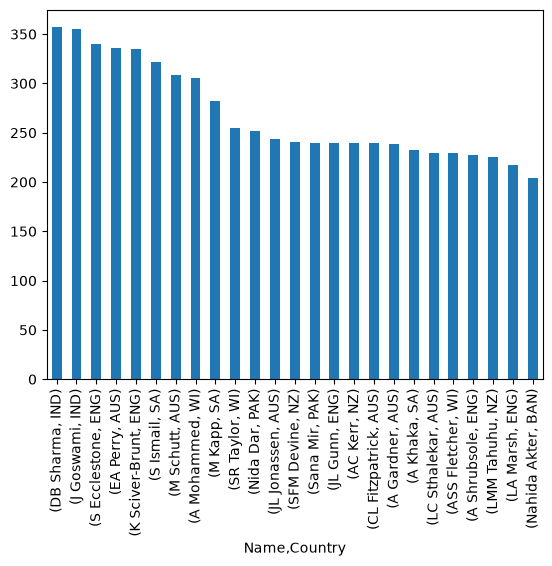

In [80]:
# Plotting the top wicket-takers of all time
most_wickets = df_women_bowlers.groupby(["Name", "Country"])["Wkts"].sum().sort_values(ascending = False)
most_wickets.head(25).to_csv("all_bowlers.csv")
most_wickets.head(25).plot(x = "Name", y = "Wkts", kind = "bar")

In [56]:
most_wickets.head(15)

Name            Country
DB Sharma       IND        357
J Goswami       IND        355
S Ecclestone    ENG        338
EA Perry        AUS        336
K Sciver-Brunt  ENG        335
S Ismail        SA         322
M Schutt        AUS        309
A Mohammed      WI         305
M Kapp          SA         282
SR Taylor       WI         255
Nida Dar        PAK        252
JL Jonassen     AUS        244
SFM Devine      NZ         241
Sana Mir        PAK        240
JL Gunn         ENG        240
Name: Wkts, dtype: int64

In [57]:
df_women_bowlers[df_women_bowlers["Name"] == "DB Sharma"].to_csv("sharma_stats.csv")
df_women_bowlers[df_women_bowlers["Name"] == "DB Sharma"]

,Player,Inns,Runs,Wkts,Ave,Econ,SR,Format,Name,Country,Category
7,DB Sharma (IND-W),123,4598,166,27.69,4.45,37.3,One Dayers,DB Sharma,IND,Full Member
200,DB Sharma (IND-W),146,3349,168,19.93,6.35,18.8,T20Is,DB Sharma,IND,Full Member
443,DB Sharma (IND-W),10,439,23,19.08,2.33,48.9,Tests,DB Sharma,IND,Full Member


## Filtering out players who have less than 50 wickets in T20Is

In [24]:
full_members = df_women_bowlers[df_women_bowlers["Category"] == "Full Member"]
t20i_df = full_members[full_members["Format"] == "T20Is"]
t20i_fifty = t20i_df[t20i_df["Wkts"] > 49]
t20i_fifty.to_csv("t20i_fifty_wkts.csv")
t20i_fifty.head(10)

,Player,Inns,Runs,Wkts,Ave,Econ,SR,Format,Name,Country,Category
200,DB Sharma (IND-W),146,3349,168,19.93,6.35,18.8,T20Is,DB Sharma,IND,Full Member
203,S Ecclestone (ENG-W),112,2532,154,16.44,6.03,16.3,T20Is,S Ecclestone,ENG,Full Member
204,M Schutt (AUS-W),125,2713,152,17.84,6.39,16.7,T20Is,M Schutt,AUS,Full Member
207,Nida Dar (PAK-W),152,2910,144,20.20,5.70,21.2,T20Is,Nida Dar,PAK,Full Member
209,S Ismail (SA-W),118,2444,131,18.65,5.83,19.1,T20Is,S Ismail,SA,Full Member
210,EA Perry (AUS-W),142,2430,131,18.54,5.84,19.0,T20Is,EA Perry,AUS,Full Member
211,SFM Devine (NZ-W),134,2541,130,19.54,6.75,17.3,T20Is,SFM Devine,NZ,Full Member
215,A Mohammed (WI-W),113,2206,125,17.64,5.57,18.9,T20Is,A Mohammed,WI,Full Member
217,Nahida Akter (BAN-W),106,2141,123,17.40,5.88,17.7,T20Is,Nahida Akter,BAN,Full Member
219,K Sciver-Brunt (ENG-W),111,2188,114,19.19,5.57,20.6,T20Is,K Sciver-Brunt,ENG,Full Member


## Plotting the players with at least 50 wickets in T20Is. The red dot will show where Deepti stands

<Axes: xlabel='SR', ylabel='Econ'>

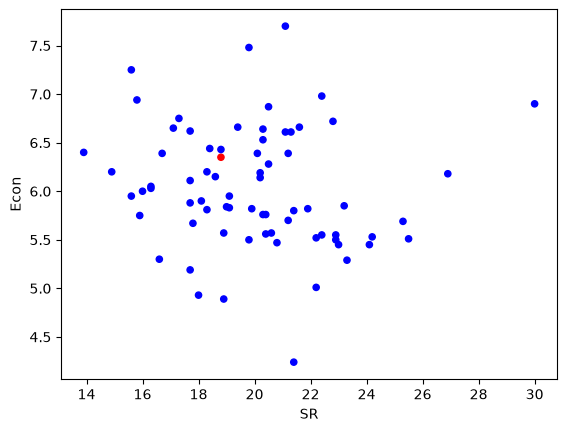

In [86]:
#Colouring Deepti Sharma's dot as red
colors = t20i_fifty["Name"].apply(lambda x: "red" if x == "DB Sharma" else "blue")
t20i_fifty.plot.scatter(x="SR", y="Econ", c=colors)

## Filtering out players who have less than 70 wickets in T20Is

In [30]:
odi_df = full_members[full_members["Format"] == "One Dayers"]
odi_seventy = odi_df[odi_df["Wkts"] > 69]
odi_seventy.to_csv("odi_seventy_wkts.csv")
odi_seventy.head(10)

,Player,Inns,Runs,Wkts,Ave,Econ,SR,Format,Name,Country,Category
0,J Goswami (IND-W),203,5622,255,22.04,3.37,39.2,One Dayers,J Goswami,IND,Full Member
1,S Ismail (SA-W),126,3812,191,19.95,3.70,32.3,One Dayers,S Ismail,SA,Full Member
2,M Kapp (SA-W),152,4388,181,24.24,3.84,37.8,One Dayers,M Kapp,SA,Full Member
3,CL Fitzpatrick (AUS-W),109,3023,180,16.79,3.01,33.4,One Dayers,CL Fitzpatrick,AUS,Full Member
4,A Mohammed (WI-W),134,3735,180,20.75,3.58,34.7,One Dayers,A Mohammed,WI,Full Member
5,K Sciver-Brunt (ENG-W),139,4081,170,24.00,3.57,40.2,One Dayers,K Sciver-Brunt,ENG,Full Member
6,EA Perry (AUS-W),139,4243,166,25.56,4.38,34.9,One Dayers,EA Perry,AUS,Full Member
7,DB Sharma (IND-W),123,4598,166,27.69,4.45,37.3,One Dayers,DB Sharma,IND,Full Member
8,SR Taylor (WI-W),139,3476,157,22.14,3.58,37.0,One Dayers,SR Taylor,WI,Full Member
9,A Khaka (SA-W),120,3970,151,26.29,4.30,36.6,One Dayers,A Khaka,SA,Full Member


## Plotting the players with at least 70 wickets in ODIs. The red dot will show where Deepti stands

<Axes: xlabel='SR', ylabel='Econ'>

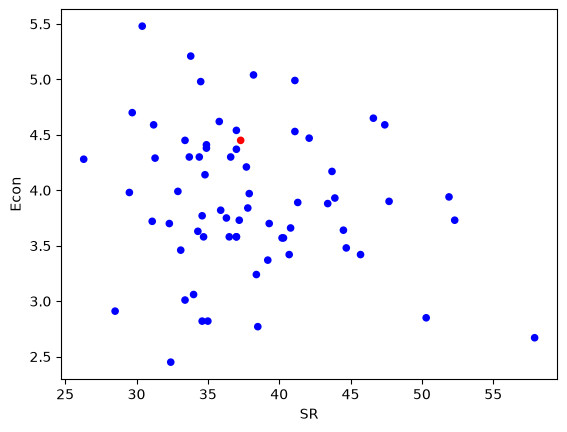

In [85]:
#Colouring Deepti Sharma's dot as red
colors = odi_seventy["Name"].apply(lambda x: "red" if x == "DB Sharma" else "blue")
odi_seventy.plot.scatter(x="SR", y="Econ", c=colors)

## Filtering out players who have less than 20 wickets in Tests.

In [34]:
test_df = full_members[full_members["Format"] == "Tests"]
test_twenty = test_df[test_df["Wkts"] > 19]
test_twenty.to_csv("test_twenty_wkts.csv")
test_twenty.head(10)

,Player,Inns,Runs,Wkts,Ave,Econ,SR,Format,Name,Country,Category
400,MB Duggan (ENG-W),27,1039,77,13.49,1.66,48.4,Tests,MB Duggan,ENG,Full Member
401,ER Wilson (AUS-W),21,803,68,11.80,1.67,42.4,Tests,ER Wilson,AUS,Full Member
402,DF Edulji (IND-W),35,1624,63,25.77,1.91,80.9,Tests,DF Edulji,IND,Full Member
403,CL Fitzpatrick (AUS-W),24,1147,60,19.11,1.91,60.0,Tests,CL Fitzpatrick,AUS,Full Member
404,S Kulkarni (IND-W),32,1647,60,27.45,2.97,55.3,Tests,S Kulkarni,IND,Full Member
405,ME Maclagan (ENG-W),27,935,60,15.58,1.63,57.2,Tests,ME Maclagan,ENG,Full Member
406,R Thompson (AUS-W),30,1040,57,18.24,1.44,75.5,Tests,R Thompson,AUS,Full Member
407,J Lord (NZ-W),23,1049,55,19.07,2.02,56.4,Tests,J Lord,NZ,Full Member
408,K Sciver-Brunt (ENG-W),25,1098,51,21.52,2.52,51.1,Tests,K Sciver-Brunt,ENG,Full Member
409,E Bakewell (ENG-W),22,831,50,16.62,1.84,53.9,Tests,E Bakewell,ENG,Full Member


## Plotting the players with at least 20 wickets in Tests. The red dot will show where Deepti stands

<Axes: xlabel='Ave', ylabel='SR'>

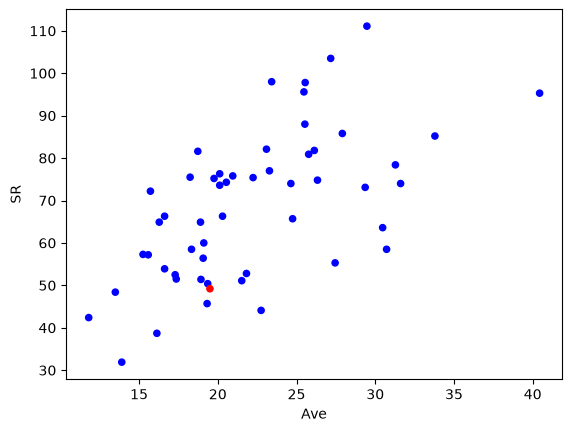

In [84]:
#Colouring Deepti Sharma's dot as red
colors = test_twenty["Name"].apply(lambda x: "red" if x == "DB Sharma" else "blue")
test_twenty.plot.scatter(x="Ave", y="SR", c=colors)

## Finding the mean of SR and Econ to plot the quadrants for the T20I scatter

In [36]:
t20_sr_mean = t20i_fifty["SR"].mean()
t20_econ_mean = t20i_fifty["Econ"].mean()
print(t20_sr_mean, t20_econ_mean)

19.970833333333335 6.03125


## Finding the mean of SR and Econ to plot the quadrants for the ODI scatter

In [41]:
odi_sr_mean = odi_seventy["SR"].mean()
odi_econ_mean = odi_seventy["Econ"].mean()
print(odi_sr_mean, odi_econ_mean)

37.938805970149254 3.9077611940298516


## Finding the mean of SR and Average to plot the quadrants for the Test scatter

In [38]:
test_avg_mean = test_twenty["Ave"].mean()
test_sr_mean = test_twenty["SR"].mean()
print(test_avg_mean, test_sr_mean)

22.208888888888882 68.42962962962963
